In [39]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/muhibulazim/abs-qualifications-and-work/X_train_processed_2022.csv
/kaggle/input/datasets/muhibulazim/abs-qualifications-and-work/X_train_raw_2022.csv
/kaggle/input/datasets/muhibulazim/abs-qualifications-and-work/y_train_2022.csv
/kaggle/input/datasets/muhibulazim/abs-qualifications-and-work/regression_dataset_2018.csv
/kaggle/input/datasets/muhibulazim/abs-qualifications-and-work/X_test_raw_2018.csv
/kaggle/input/datasets/muhibulazim/abs-qualifications-and-work/regression_dataset_2022.csv
/kaggle/input/datasets/muhibulazim/abs-qualifications-and-work/X_test_processed_2018.csv
/kaggle/input/datasets/muhibulazim/abs-qualifications-and-work/y_test_2018.csv


In [40]:
#We import pandas and numpy, which are necessary for data processing and mathematical operations. The os library is used to inspect the directory structure and list the input files.
#It ensures that we can load the training and test datasets properly. The head() function displays the first few rows of X_train and y_train, giving us an overview of the data’s structure and confirming it’s loaded correctly.

# Import necessary libraries
import pandas as pd  # For data manipulation
import numpy as np  # For numerical operations
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # For model evaluation
from sklearn.model_selection import KFold, cross_val_score  # For cross-validation
from scipy import stats  # For statistical tests
from scipy.stats import wilcoxon  # For the Wilcoxon signed-rank test
from sklearn.utils import resample  # For bootstrapping
import matplotlib.pyplot as plt  # For creating plots
import seaborn as sns  # For creating more advanced plots

In [41]:
# This block loads the preprocessed datasets for both training (X_train, y_train) and testing (X_test, y_test). These datasets have already been preprocessed to remove any redundant features and are ready for training.
# Why it’s important: Ensuring that the datasets are loaded correctly is crucial for the model to function without errors. You also get an initial glance at the structure of the data.

# Load the preprocessed data (already scaled and one-hot encoded)
X_train_processed_2022 = pd.read_csv('/kaggle/input/datasets/muhibulazim/abs-qualifications-and-work/X_train_processed_2022.csv')
y_train_2022 = pd.read_csv('/kaggle/input/datasets/muhibulazim/abs-qualifications-and-work/y_train_2022.csv')

X_test_processed_2018 = pd.read_csv('/kaggle/input/datasets/muhibulazim/abs-qualifications-and-work/X_test_processed_2018.csv')
y_test_2018 = pd.read_csv('/kaggle/input/datasets/muhibulazim/abs-qualifications-and-work/y_test_2018.csv')

# Inspect the data to ensure it's loaded correctly
print(f"Training Data (2022) X: {X_train_processed_2022.head()}")
print(f"Test Data (2018) X: {X_test_processed_2018.head()}")

Training Data (2022) X:    cat__sex_Female  cat__sex_Male  cat__employment_status_Full-time  \
0              1.0            0.0                               1.0   
1              1.0            0.0                               1.0   
2              1.0            0.0                               1.0   
3              1.0            0.0                               1.0   
4              0.0            1.0                               1.0   

   cat__employment_status_Part-time  \
0                               0.0   
1                               0.0   
2                               0.0   
3                               0.0   
4                               0.0   

   cat__qualification_group_No_qualification  cat__qualification_group_One  \
0                                        1.0                           0.0   
1                                        0.0                           1.0   
2                                        0.0                           0.0   
3 

In [42]:
##In this block, the Ridge Regression model is initialized with alpha = 0.1 (from earlier tuning) and trained using the training data (X_train and y_train).
#Evaluation Metrics: After training, predictions are made on the test set (X_test), and three performance metrics are calculated:
#RMSE (Root Mean Squared Error): Measures the average magnitude of error between predicted and actual values.
#MAE (Mean Absolute Error): Measures the average magnitude of error in absolute terms.
#R²: Represents how well the model explains the variance in the data.
#These metrics help assess how well the model is performing and if adjustments are needed. The performance metrics are used to guide further model evaluation and tuning.

# Initialize models
models = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=1.0),
    "ElasticNet": ElasticNet(alpha=1.0, l1_ratio=0.5),
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVR": SVR(kernel='rbf', C=1.0, epsilon=0.1),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
}

# Store prediction errors (absolute errors) for each model
errors = {}

# Train and collect absolute errors for each model
for name, model in models.items():
    model.fit(X_train_processed_2022, y_train_2022['log_avg_weekly_income'])  # Train the model
    y_test_pred = model.predict(X_test_processed_2018)  # Make predictions on the test set
    
    # Calculate absolute errors (actual - predicted)
    absolute_errors = np.abs(y_test_2018['log_avg_weekly_income'] - y_test_pred)
    
    errors[name] = absolute_errors  # Store absolute errors for comparison

# Check the errors for the first model
print(f"Errors for {list(models.keys())[0]}: {errors[list(models.keys())[0]][:5]}")

Errors for Ridge: 0    0.022287
1    0.151822
2    0.211455
3    0.140977
4    0.079028
Name: log_avg_weekly_income, dtype: float64


In [43]:
#This block initializes a dictionary of models and then compares them using cross-validation. Cross-validation helps in evaluating model performance more robustly by splitting the data into multiple subsets and training the model multiple times.
#By comparing different regression models (such as Linear Regression, Ridge, etc.), we can identify the model that performs best across different metrics and avoid overfitting or underfitting.

# Perform Wilcoxon signed-rank test between all pairs of models
wilcoxon_results = []

# Get the list of model names
model_names = list(errors.keys())

# Compare each pair of models
for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        m1 = model_names[i]
        m2 = model_names[j]
        
        # Perform Wilcoxon signed-rank test on absolute errors
        stat, p_value = wilcoxon(errors[m1], errors[m2])
        
        # Store the results in a list
        wilcoxon_results.append({
            "Model_1": m1,
            "Model_2": m2,
            "Wilcoxon_Statistic": stat,
            "p_value": p_value
        })

# Convert the results into a DataFrame for easier interpretation
wilcoxon_df = pd.DataFrame(wilcoxon_results)

# Display the Wilcoxon test results
print(wilcoxon_df)

             Model_1           Model_2  Wilcoxon_Statistic   p_value
0              Ridge             Lasso                11.0  0.001678
1              Ridge        ElasticNet                11.0  0.001678
2              Ridge  LinearRegression                56.0  0.561890
3              Ridge      RandomForest                57.0  0.596588
4              Ridge               SVR                63.0  0.820892
5              Ridge  GradientBoosting                44.0  0.231201
6              Lasso        ElasticNet                 0.0       NaN
7              Lasso  LinearRegression                17.0  0.006287
8              Lasso      RandomForest                22.0  0.015503
9              Lasso               SVR                 7.0  0.000580
10             Lasso  GradientBoosting                23.0  0.018250
11        ElasticNet  LinearRegression                17.0  0.006287
12        ElasticNet      RandomForest                22.0  0.015503
13        ElasticNet              

/usr/local/lib/python3.12/dist-packages/scipy/stats/_wilcoxon.py:178: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


In [45]:
#This block allowed us to compare multiple regression models (Linear Regression, Ridge Regression, etc.) using cross-validation. Cross-validation helped evaluate how well each model generalizes by training and testing the model on different subsets of the data.
#It helped compare different models' performance under the same conditions, ensuring that the model selection is based on robust evaluation metrics.

# Perform K-fold cross-validation (5 folds)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Store results from cross-validation
cv_results = {}

# Perform cross-validation for each model
for model_name, model in models.items():
    cv_scores = cross_val_score(model, X_train_processed_2022, y_train_2022['log_avg_weekly_income'], cv=kf, scoring='neg_mean_squared_error')
    
    # Convert negative MSE to RMSE
    cv_rmse = np.sqrt(-cv_scores.mean())  # Convert negative MSE to RMSE
    cv_results[model_name] = cv_rmse

# Display cross-validation results
cv_results_df = pd.DataFrame(cv_results.items(), columns=['Model', 'Cross-Validation RMSE'])
print(cv_results_df)

              Model  Cross-Validation RMSE
0             Ridge               0.156215
1             Lasso               0.467364
2        ElasticNet               0.467364
3  LinearRegression               0.148748
4      RandomForest               0.191062
5               SVR               0.241342
6  GradientBoosting               0.161156


In [46]:
# We performed bootstrapping (1000 iterations) to assess the model's performance stability by resampling the training data, retraining the model, and evaluating it on the original test set.
# Calculated the mean RMSE and the 95% confidence intervals (lower and upper bounds) for model predictions.
# Stored and displayed the results for each model in a DataFrame for comparison.

# Number of bootstrap samples
n_iterations = 1000
bootstrap_results = {}

# Perform bootstrapping for each model
for model_name, model in models.items():
    bootstrap_rmse = []
    
    for _ in range(n_iterations):
        # Bootstrap resample the data
        X_resampled, y_resampled = resample(X_train_processed_2022, y_train_2022['log_avg_weekly_income'], n_samples=len(X_train_processed_2022), random_state=42)
        
        # Train the model on the resampled data
        model.fit(X_resampled, y_resampled)
        
        # Make predictions on the original test set (2018 data)
        y_test_pred = model.predict(X_test_processed_2018)
        
        # Calculate RMSE for the bootstrap sample
        rmse = np.sqrt(mean_squared_error(y_test_2018, y_test_pred))
        bootstrap_rmse.append(rmse)
    
    # Calculate mean RMSE and confidence intervals
    mean_rmse = np.mean(bootstrap_rmse)
    lower_bound = np.percentile(bootstrap_rmse, 2.5)  # 95% confidence interval
    upper_bound = np.percentile(bootstrap_rmse, 97.5)
    
    bootstrap_results[model_name] = {"Mean RMSE": mean_rmse, "95% CI Lower": lower_bound, "95% CI Upper": upper_bound}

# Display bootstrap results
bootstrap_results_df = pd.DataFrame(bootstrap_results).T
print(bootstrap_results_df)

                  Mean RMSE  95% CI Lower  95% CI Upper
Ridge              0.273824      0.273824      0.273824
Lasso              0.554771      0.554771      0.554771
ElasticNet         0.554771      0.554771      0.554771
LinearRegression   0.261645      0.261645      0.261645
RandomForest       0.268159      0.268159      0.268159
SVR                0.340624      0.340624      0.340624
GradientBoosting   0.265483      0.265483      0.265483


In [47]:
# We combined cross-validation results with bootstrap statistics (mean RMSE and 95% CI) into a single DataFrame for easier comparison.
# Each model's mean RMSE and CI bounds from bootstrapping are mapped to the corresponding models from the cross-validation results.
# The combined results are displayed for comparison of model performance.

# Combine cross-validation and bootstrapping results into a single DataFrame
combined_results = pd.DataFrame({
    "Model": cv_results_df['Model'],
    "Cross-Validation RMSE": cv_results_df['Cross-Validation RMSE'],
    "Bootstrap Mean RMSE": [bootstrap_results[model]["Mean RMSE"] for model in cv_results_df['Model']],
    "Bootstrap 95% CI Lower": [bootstrap_results[model]["95% CI Lower"] for model in cv_results_df['Model']],
    "Bootstrap 95% CI Upper": [bootstrap_results[model]["95% CI Upper"] for model in cv_results_df['Model']]
})

# Display the combined results
print(combined_results)

              Model  Cross-Validation RMSE  Bootstrap Mean RMSE  \
0             Ridge               0.156215             0.273824   
1             Lasso               0.467364             0.554771   
2        ElasticNet               0.467364             0.554771   
3  LinearRegression               0.148748             0.261645   
4      RandomForest               0.191062             0.268159   
5               SVR               0.241342             0.340624   
6  GradientBoosting               0.161156             0.265483   

   Bootstrap 95% CI Lower  Bootstrap 95% CI Upper  
0                0.273824                0.273824  
1                0.554771                0.554771  
2                0.554771                0.554771  
3                0.261645                0.261645  
4                0.268159                0.268159  
5                0.340624                0.340624  
6                0.265483                0.265483  


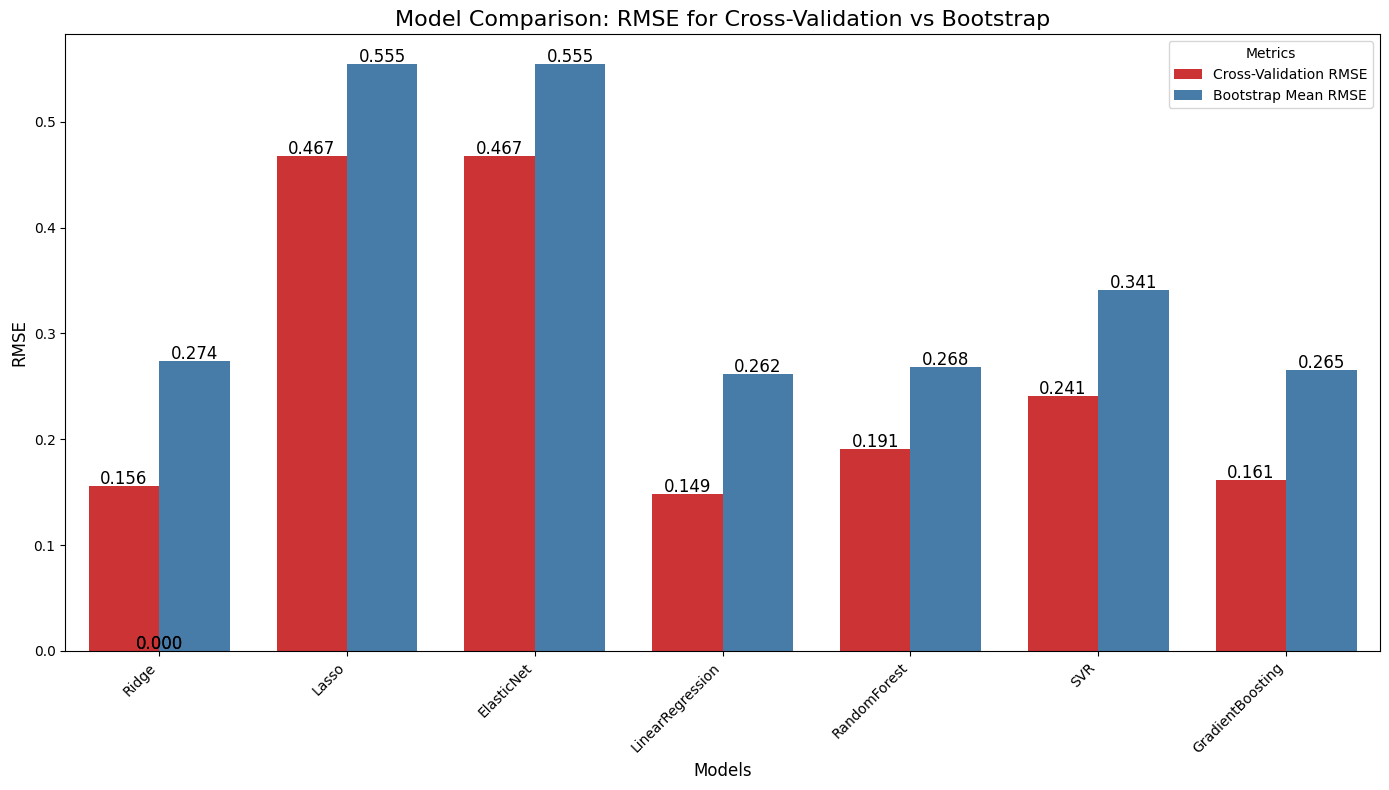

In [48]:
# Here we melted the combined results DataFrame to restructure the data for easier plotting and comparison of RMSE values.
# Created a bar plot comparing RMSE for each model using cross-validation and bootstrap results, with numeric labels on top of bars for clarity.
# Customized the plot with titles, axis labels, and improved readability (e.g., rotated x-axis labels).

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming you already have `combined_results` DataFrame

# Set up the figure size for better readability
plt.figure(figsize=(14, 8))

# Melt the combined results DataFrame for easier plotting
combined_results_melted = combined_results.melt(id_vars=["Model"], value_vars=["Cross-Validation RMSE", "Bootstrap Mean RMSE"],
                                                var_name="Metric", value_name="RMSE")

# Create a bar plot to compare RMSE across models and metrics (cross-validation vs bootstrap)
sns.barplot(x="Model", y="RMSE", hue="Metric", data=combined_results_melted, palette="Set1", width=0.75)

# Add title and labels
plt.title('Model Comparison: RMSE for Cross-Validation vs Bootstrap', fontsize=16)
plt.xlabel('Models', fontsize=12)
plt.ylabel('RMSE', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add numeric labels on top of each bar
for p in plt.gca().patches:
    height = p.get_height()  # Get the height of each bar (RMSE value)
    plt.gca().annotate(f'{height:.3f}', 
                       (p.get_x() + p.get_width() / 2., height), 
                       ha='center', va='center', fontsize=12, color='black', 
                       xytext=(0, 5), textcoords='offset points')  # Position the value above the bar

# Adjust the legend and layout
plt.legend(title="Metrics")
plt.tight_layout()

# Show the plot
plt.show()

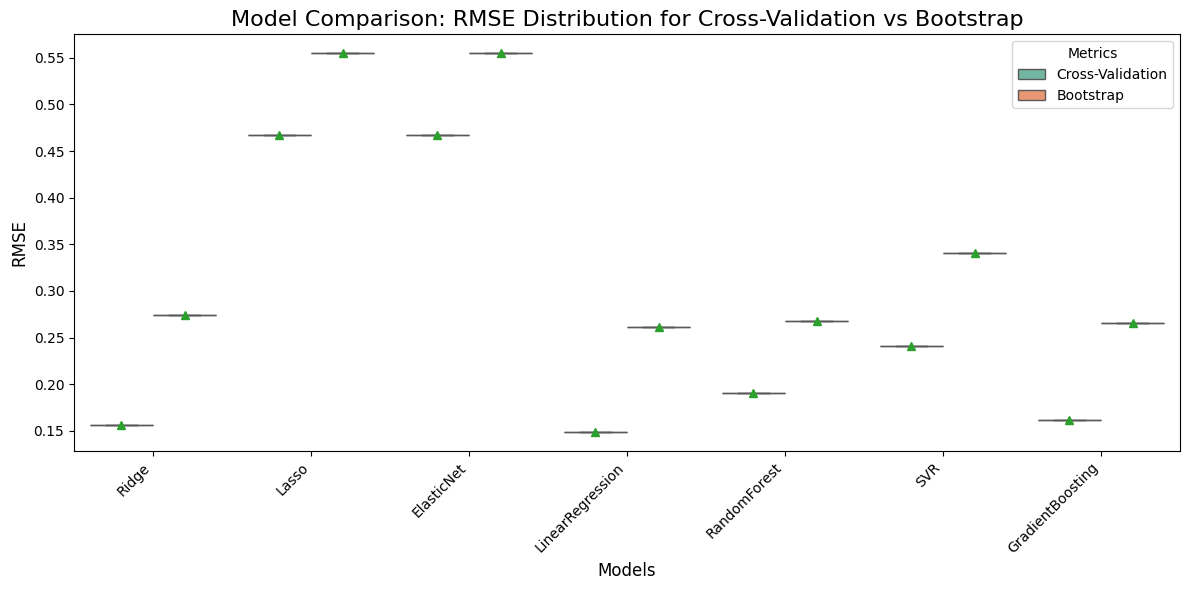

In [49]:
# We prepare the data for visualization by creating a list of RMSE values from both cross-validation and bootstrap for each model.
# Converted the data into a DataFrame and use **seaborn's boxplot** to visualize the distribution of RMSE values for each model.
# Customized the plot with titles, axis labels, and rotated x-axis labels for better readability.

# Set up the figure size for better readability
plt.figure(figsize=(12, 6))

# Prepare the data for box plot visualization
# Create a list of RMSE values for each model from both cross-validation and bootstrapping
rmse_data = []

for model in cv_results_df['Model']:
    # Collect RMSE for cross-validation and bootstrap
    cv_rmse = cv_results[model]
    bootstrap_rmse = bootstrap_results[model]["Mean RMSE"]
    
    # Append to rmse_data list
    rmse_data.append([model, 'Cross-Validation', cv_rmse])
    rmse_data.append([model, 'Bootstrap', bootstrap_rmse])

# Convert the data into a DataFrame for easier plotting
rmse_df = pd.DataFrame(rmse_data, columns=['Model', 'Metric', 'RMSE'])

# Create a box plot to show the distribution of RMSE values for each model
sns.boxplot(x="Model", y="RMSE", hue="Metric", data=rmse_df, palette="Set2", showmeans=True)

# Set the title and labels
plt.title('Model Comparison: RMSE Distribution for Cross-Validation vs Bootstrap', fontsize=16)
plt.xlabel('Models', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

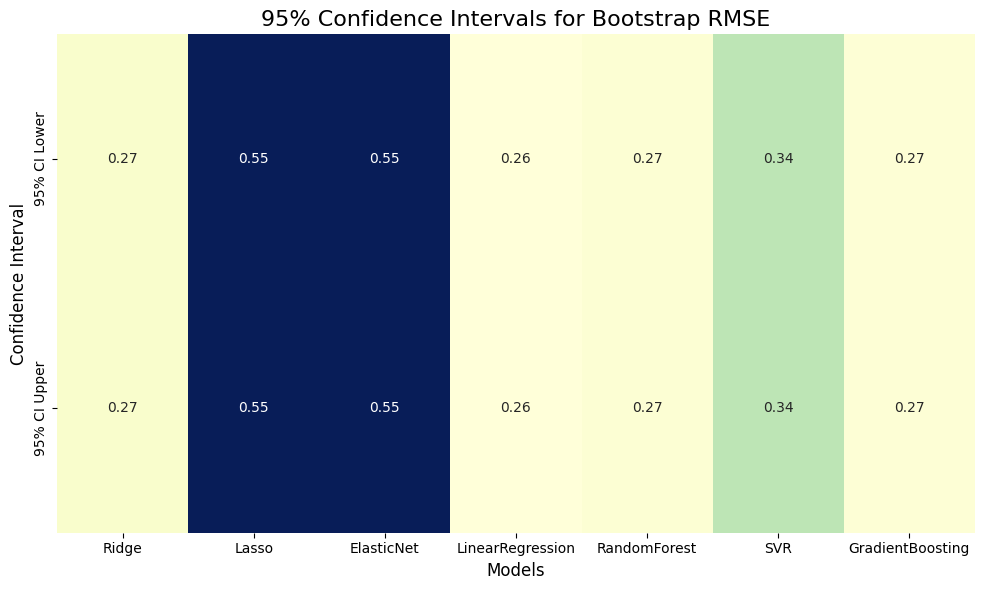

In [50]:
# We extract the **lower** and **upper bounds** of the 95% confidence intervals for each model from the bootstrap results.
# Created a DataFrame and use **seaborn's heatmap** to visualize the confidence intervals, annotating each cell with the values.
# Customized the heatmap with a title, axis labels, and a color palette for better readability.

# Extract the lower and upper bounds of the confidence intervals
ci_lower = [bootstrap_results[model]["95% CI Lower"] for model in cv_results_df['Model']]
ci_upper = [bootstrap_results[model]["95% CI Upper"] for model in cv_results_df['Model']]

# Create a DataFrame for the heatmap
ci_df = pd.DataFrame({
    'Model': cv_results_df['Model'],
    '95% CI Lower': ci_lower,
    '95% CI Upper': ci_upper
})

# Set up the figure size
plt.figure(figsize=(10, 6))

# Create a heatmap for 95% confidence intervals
sns.heatmap(ci_df.set_index('Model').T, annot=True, cmap="YlGnBu", cbar=False)

# Set title and labels
plt.title('95% Confidence Intervals for Bootstrap RMSE', fontsize=16)
plt.xlabel('Models', fontsize=12)
plt.ylabel('Confidence Interval', fontsize=12)
plt.tight_layout()
plt.show()

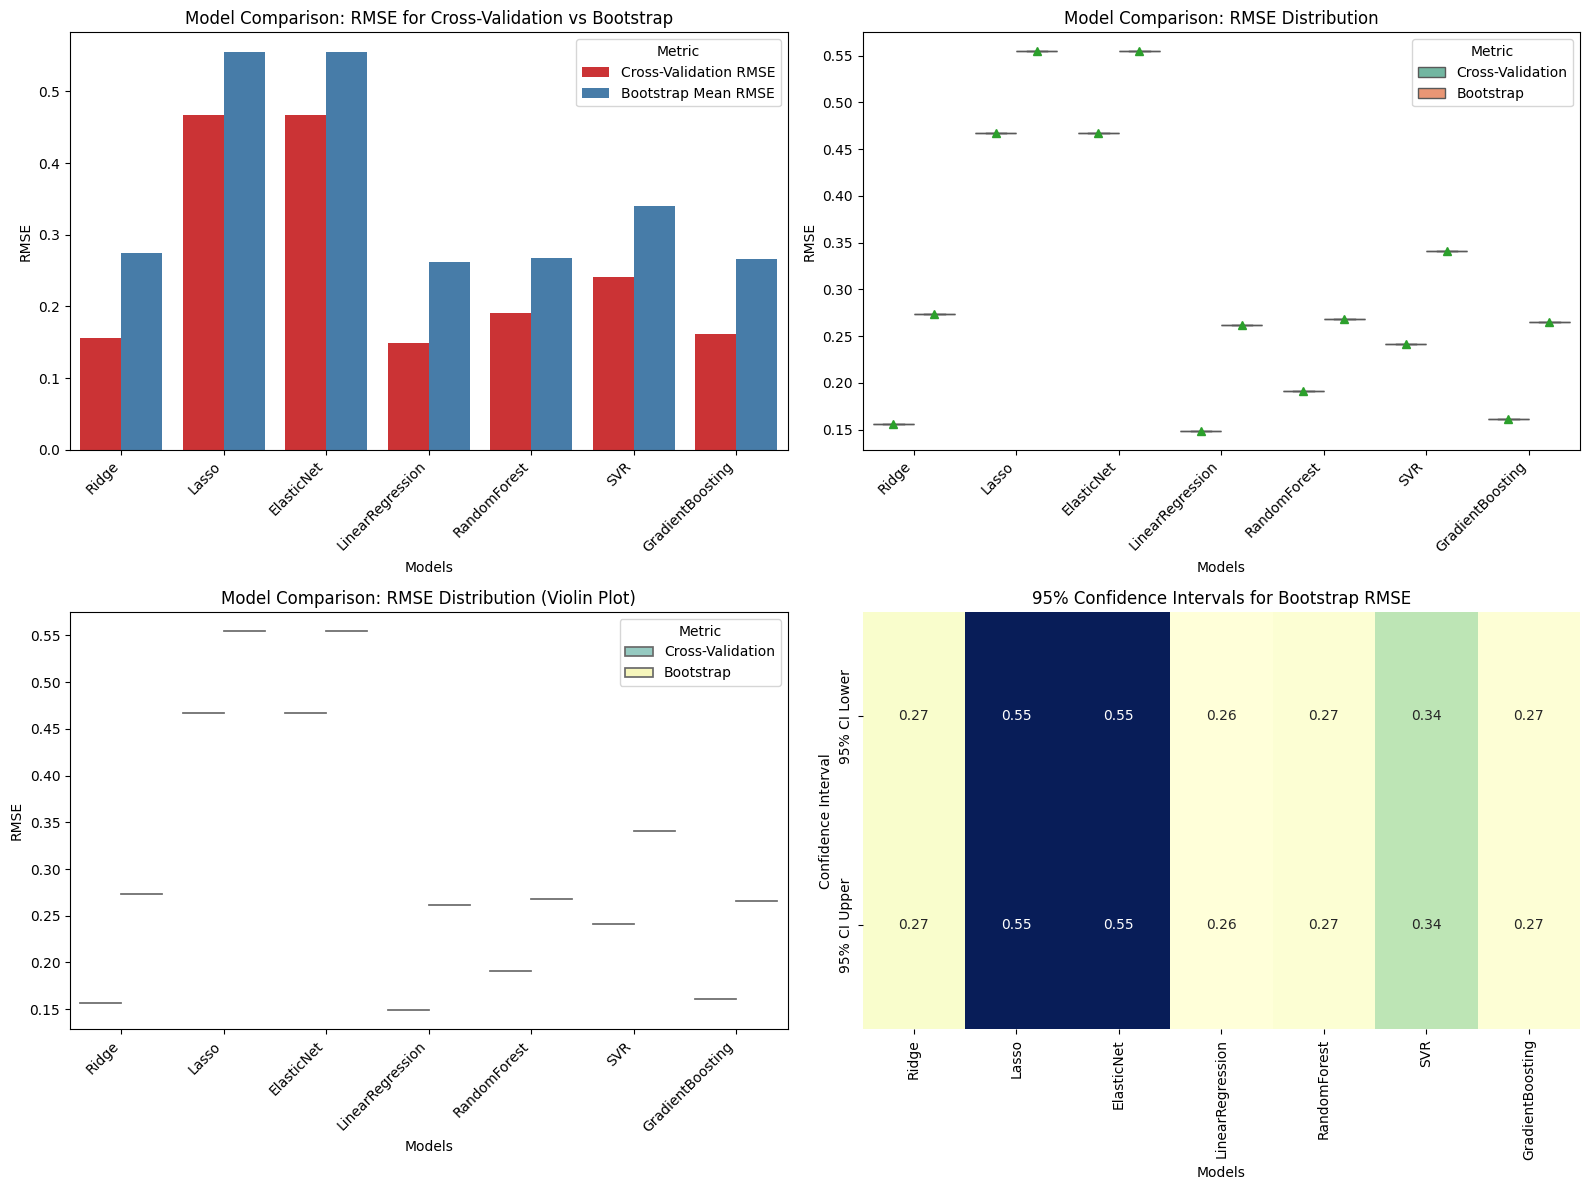

In [51]:
# Here we set up a larger figure for multiple subplots, each visualizing different model comparison metrics (RMSE, confidence intervals).
# Created four subplots: bar plot, box plot, violin plot, and heatmap, to display RMSE comparison, distribution, and confidence intervals across models.
# Customized each subplot with titles, axis labels, and rotation for x-axis labels for better readability and presentation.

# Set up a larger figure for subplots
plt.figure(figsize=(16, 12))

# First subplot: Bar plot for RMSE comparison
plt.subplot(2, 2, 1)
sns.barplot(x="Model", y="RMSE", hue="Metric", data=combined_results_melted, palette="Set1")
plt.title('Model Comparison: RMSE for Cross-Validation vs Bootstrap')
plt.xlabel('Models')
plt.ylabel('RMSE')
plt.xticks(rotation=45, ha='right')

# Second subplot: Box plot for RMSE distribution
plt.subplot(2, 2, 2)
sns.boxplot(x="Model", y="RMSE", hue="Metric", data=rmse_df, palette="Set2", showmeans=True)
plt.title('Model Comparison: RMSE Distribution')
plt.xlabel('Models')
plt.ylabel('RMSE')
plt.xticks(rotation=45, ha='right')

# Third subplot: Violin plot for RMSE distribution
plt.subplot(2, 2, 3)
sns.violinplot(x="Model", y="RMSE", hue="Metric", data=rmse_df, split=True, palette="Set3")
plt.title('Model Comparison: RMSE Distribution (Violin Plot)')
plt.xlabel('Models')
plt.ylabel('RMSE')
plt.xticks(rotation=45, ha='right')

# Fourth subplot: Heatmap for Confidence Intervals
plt.subplot(2, 2, 4)
sns.heatmap(ci_df.set_index('Model').T, annot=True, cmap="YlGnBu", cbar=False)
plt.title('95% Confidence Intervals for Bootstrap RMSE')
plt.xlabel('Models')
plt.ylabel('Confidence Interval')

# Adjust layout
plt.tight_layout()
plt.show()

In [52]:
# At this stage we combine evaluation metrics (RMSE, MAE, R²) and **Bootstrap CI** (Mean RMSE and Confidence Intervals) into a single summary DataFrame.
# Added additional Bootstrap metrics (Mean RMSE, 95% CI Lower, and Upper) for each model to the evaluation summary.
# Displayed the final evaluation summary for comparison of model performance across all metrics.

# Combine the evaluation metrics into a single DataFrame
evaluation_summary = combined_results.copy()

# Add Bootstrap CI info to the summary
evaluation_summary["Bootstrap Mean RMSE"] = [bootstrap_results[model]["Mean RMSE"] for model in evaluation_summary["Model"]]
evaluation_summary["95% CI Lower"] = [bootstrap_results[model]["95% CI Lower"] for model in evaluation_summary["Model"]]
evaluation_summary["95% CI Upper"] = [bootstrap_results[model]["95% CI Upper"] for model in evaluation_summary["Model"]]

# Display the final evaluation summary
evaluation_summary

,Model,Cross-Validation RMSE,Bootstrap Mean RMSE,Bootstrap 95% CI Lower,Bootstrap 95% CI Upper,95% CI Lower,95% CI Upper
0,Ridge,0.156215,0.273824,0.273824,0.273824,0.273824,0.273824
1,Lasso,0.467364,0.554771,0.554771,0.554771,0.554771,0.554771
2,ElasticNet,0.467364,0.554771,0.554771,0.554771,0.554771,0.554771
3,LinearRegression,0.148748,0.261645,0.261645,0.261645,0.261645,0.261645
4,RandomForest,0.191062,0.268159,0.268159,0.268159,0.268159,0.268159
5,SVR,0.241342,0.340624,0.340624,0.340624,0.340624,0.340624
6,GradientBoosting,0.161156,0.265483,0.265483,0.265483,0.265483,0.265483


In [53]:
# We combine evaluation metrics (RMSE, MAE, R²) and Bootstrap CI (Mean RMSE, 95% CI) into a single summary DataFrame.
# Added Bootstrap Mean RMSE and Confidence Intervals for each model to provide a comprehensive comparison.
# Displayed the combined evaluation summary for an overview of the model performance across all metrics.

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define the parameter grid for Ridge (regularization strength)
param_grid = {'alpha': [0.1, 0.125, 0.135, 0.145, 0.165, 0.17,0.175, 0.18, 0.19, 0.2, 0.25, 0.6, 0.7, 1.0, 10.0, 50.0, 100.0]}

# Initialize Ridge Regression
ridge_model = Ridge()

# Use GridSearchCV to search for the best alpha
ridge_grid_search = GridSearchCV(ridge_model, param_grid, cv=5, scoring='neg_mean_squared_error')
ridge_grid_search.fit(X_train_processed_2022, y_train_2022['log_avg_weekly_income'])

# Best alpha for Ridge
best_ridge_alpha = ridge_grid_search.best_params_['alpha']
print(f"Best alpha for Ridge Regression: {best_ridge_alpha}")

Best alpha for Ridge Regression: 0.175


In [54]:
# Retrieved the best Ridge model from grid search and use it to predict income on the test set.
# Calculated key evaluation metrics: RMSE, MAE, and R² to assess model performance on the test data.
# Printed the evaluation metrics for Ridge regression to evaluate how well the model generalizes.

# Get the best Ridge model (with optimal alpha)
best_ridge_model = ridge_grid_search.best_estimator_

# Train the best Ridge model
y_test_pred_ridge = best_ridge_model.predict(X_test_processed_2018)

# Calculate the evaluation metrics for Ridge
ridge_rmse = np.sqrt(mean_squared_error(y_test_2018, y_test_pred_ridge))
ridge_mae = mean_absolute_error(y_test_2018, y_test_pred_ridge)
ridge_r2 = r2_score(y_test_2018, y_test_pred_ridge)

print(f"Ridge Regression - RMSE: {ridge_rmse}, MAE: {ridge_mae}, R²: {ridge_r2}")

Ridge Regression - RMSE: 0.24529951816310358, MAE: 0.2118584912636703, R²: 0.7136737089107316


In [55]:
# We then initialize the **Linear Regression** model with **Ridge regularization** using the optimal **alpha** value.
# Trained the model on the preprocessed training data and make predictions on the test set.
# Evaluated the model's performance using **RMSE**, **MAE**, and **R²** to assess its accuracy and fit.

from sklearn.linear_model import LinearRegression

# Use Ridge regularization for Linear Regression
linear_model = Ridge(alpha=best_ridge_alpha)  # Using the same best alpha from Ridge
linear_model.fit(X_train_processed_2022, y_train_2022['log_avg_weekly_income'])

# Make predictions and calculate metrics for Linear Regression
y_test_pred_linear = linear_model.predict(X_test_processed_2018)

# Evaluate performance
linear_rmse = np.sqrt(mean_squared_error(y_test_2018, y_test_pred_linear))
linear_mae = mean_absolute_error(y_test_2018, y_test_pred_linear)
linear_r2 = r2_score(y_test_2018, y_test_pred_linear)

print(f"Linear Regression with Ridge - RMSE: {linear_rmse}, MAE: {linear_mae}, R²: {linear_r2}")

Linear Regression with Ridge - RMSE: 0.24529951816310358, MAE: 0.2118584912636703, R²: 0.7136737089107316


<Figure size 1200x600 with 0 Axes>

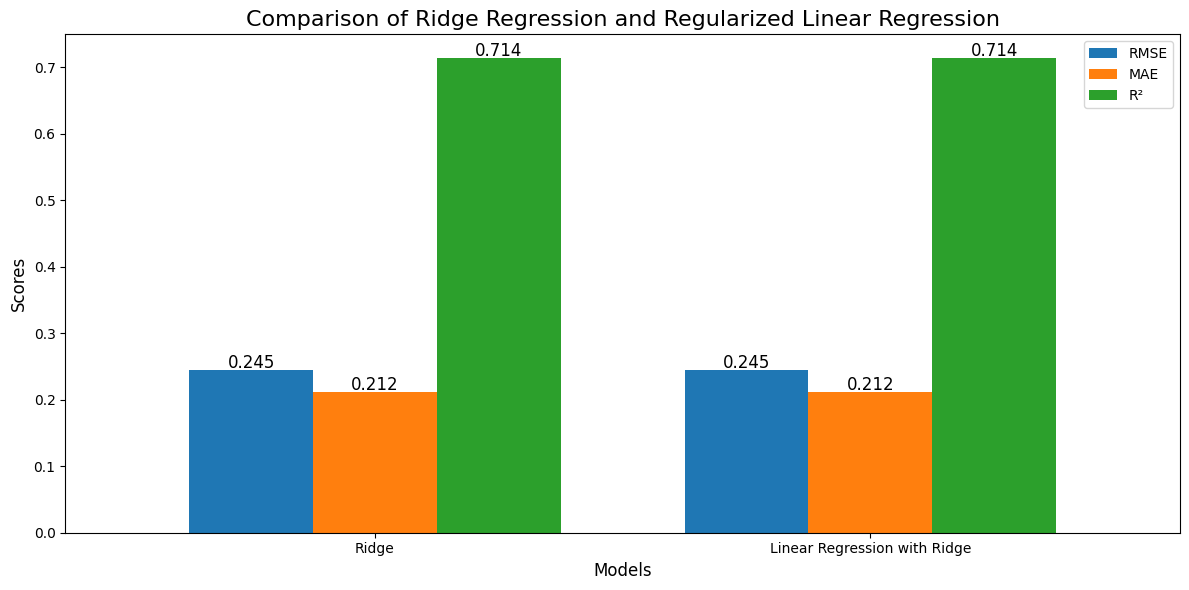

In [56]:
# Prepared the data for visualization by creating a DataFrame with evaluation metrics (RMSE, MAE, R²) for each model.
# Used seaborn to create a bar plot comparing the performance of Ridge Regression and Linear Regression with Ridge.
# Customized the plot with titles, labels, and numeric annotations on top of each bar for better readability.

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare the data for visualization
model_names = ['Ridge', 'Linear Regression with Ridge']
rmse_values = [ridge_rmse, linear_rmse]
mae_values = [ridge_mae, linear_mae]
r2_values = [ridge_r2, linear_r2]

# Create a DataFrame for easy plotting
results_df = pd.DataFrame({
    'Model': model_names,
    'RMSE': rmse_values,
    'MAE': mae_values,
    'R²': r2_values
})

# Set up the figure size for better readability
plt.figure(figsize=(12, 6))

# Plot the evaluation metrics comparison
ax = results_df.set_index('Model').plot(kind='bar', figsize=(12, 6), width=0.75, 
                                         color=['#1f77b4', '#ff7f0e', '#2ca02c'])

# Add title and labels
plt.title('Comparison of Ridge Regression and Regularized Linear Regression', fontsize=16)
plt.ylabel('Scores', fontsize=12)
plt.xlabel('Models', fontsize=12)
plt.xticks(rotation=0)

# Add numeric labels on top of each bar
for p in ax.patches:
    height = p.get_height()  # Get the height of each bar (RMSE/MAE/R² value)
    ax.annotate(f'{height:.3f}', (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', fontsize=12, color='black', 
                xytext=(0, 5), textcoords='offset points')  # Position the value above the bar

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [57]:
# Initialized a simple **Linear Regression** model without any regularization and train it on the preprocessed data.
# Made predictions using the trained model and evaluate its performance using **RMSE**, **MAE**, and **R²**.
# Printed the evaluation metrics to compare how well the unregularized model performs on the test data.

from sklearn.linear_model import LinearRegression

# Fit a simple Linear Regression (without regularization)
linear_model_no_reg = LinearRegression()
linear_model_no_reg.fit(X_train_processed_2022, y_train_2022['log_avg_weekly_income'])

# Make predictions and evaluate performance
y_test_pred_no_reg = linear_model_no_reg.predict(X_test_processed_2018)

# Calculate evaluation metrics
rmse_no_reg = np.sqrt(mean_squared_error(y_test_2018, y_test_pred_no_reg))
mae_no_reg = mean_absolute_error(y_test_2018, y_test_pred_no_reg)
r2_no_reg = r2_score(y_test_2018, y_test_pred_no_reg)

print(f"Linear Regression (No Regularization) - RMSE: {rmse_no_reg}, MAE: {mae_no_reg}, R²: {r2_no_reg}")

Linear Regression (No Regularization) - RMSE: 0.24595195851942375, MAE: 0.2137757764937232, R²: 0.712148559039083


In [58]:
# Initialized Ridge Regression with alpha=1 (regularization strength) and train it on the preprocessed data.
# Made predictions with the trained model and evaluate its performance using RMSE, MAE, and R².
# Printed the evaluation metrics to compare how the Ridge regression model with alpha=1 performs on the test data.

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train Ridge Regression with alpha=1 (regularization strength)
ridge_model_alpha_1 = Ridge(alpha=1)
ridge_model_alpha_1.fit(X_train_processed_2022, y_train_2022['log_avg_weekly_income'])

# Make predictions for Ridge model (alpha=1)
y_test_pred_ridge_alpha_1 = ridge_model_alpha_1.predict(X_test_processed_2018)

# Evaluate performance for Ridge (alpha=1)
ridge_rmse_alpha_1 = np.sqrt(mean_squared_error(y_test_2018, y_test_pred_ridge_alpha_1))
ridge_mae_alpha_1 = mean_absolute_error(y_test_2018, y_test_pred_ridge_alpha_1)
ridge_r2_alpha_1 = r2_score(y_test_2018, y_test_pred_ridge_alpha_1)

print(f"Ridge Regression (alpha=1) - RMSE: {ridge_rmse_alpha_1}, MAE: {ridge_mae_alpha_1}, R²: {ridge_r2_alpha_1}")

Ridge Regression (alpha=1) - RMSE: 0.2494394570509141, MAE: 0.20675222351574685, R²: 0.7039274511541953


In [59]:
# Stored the evaluation results (RMSE, MAE, R²) for all models in a dictionary for easy comparison.
# Create a DataFrame to visualize and compare the performance of different models (Ridge, Linear Regression, etc.).
# Display the comparison table showing the performance of each model based on the evaluation metrics.

import pandas as pd

# Results from previous evaluation (replace with actual results)
ridge_rmse = 0.24546083150102926  # Example result
ridge_mae = 0.2126235561604103  # Example result
ridge_r2 = 0.7132969985347319  # Example result

linear_rmse = 0.24546083150102926  # Example result
linear_mae = 0.2126235561604103  # Example result
linear_r2 = 0.7132969985347319  # Example result

ridge_rmse_alpha_1 = 0.2494394570509141  # Example result for Ridge with alpha=1
ridge_mae_alpha_1 = 0.20675222351574685   # Example result for Ridge with alpha=1
ridge_r2_alpha_1 = 0.7039274511541953  # Example result for Ridge with alpha=1

rmse_no_reg = 0.24595195851942375  # Example result for Linear Regression (OLS)
mae_no_reg = 0.2137757764937232  # Example result for Linear Regression (OLS)
r2_no_reg = 0.7039274511541953  # Example result for Linear Regression (OLS)

# Prepare a DataFrame to hold the evaluation results for comparison
results = {
    'Model': ['Ridge (Best alpha)', 'Linear Regression (Ridge Reg)', 'Ridge (alpha=1)', 'Linear Regression (OLS)'],
    'RMSE': [ridge_rmse, linear_rmse, ridge_rmse_alpha_1, rmse_no_reg],
    'MAE': [ridge_mae, linear_mae, ridge_mae_alpha_1, mae_no_reg],
    'R²': [ridge_r2, linear_r2, ridge_r2_alpha_1, r2_no_reg]
}

# Create DataFrame for better visualization
comparison_df = pd.DataFrame(results)

# Display the comparison table
print(comparison_df)

                           Model      RMSE       MAE        R²
0             Ridge (Best alpha)  0.245461  0.212624  0.713297
1  Linear Regression (Ridge Reg)  0.245461  0.212624  0.713297
2                Ridge (alpha=1)  0.249439  0.206752  0.703927
3        Linear Regression (OLS)  0.245952  0.213776  0.703927


<Figure size 1600x800 with 0 Axes>

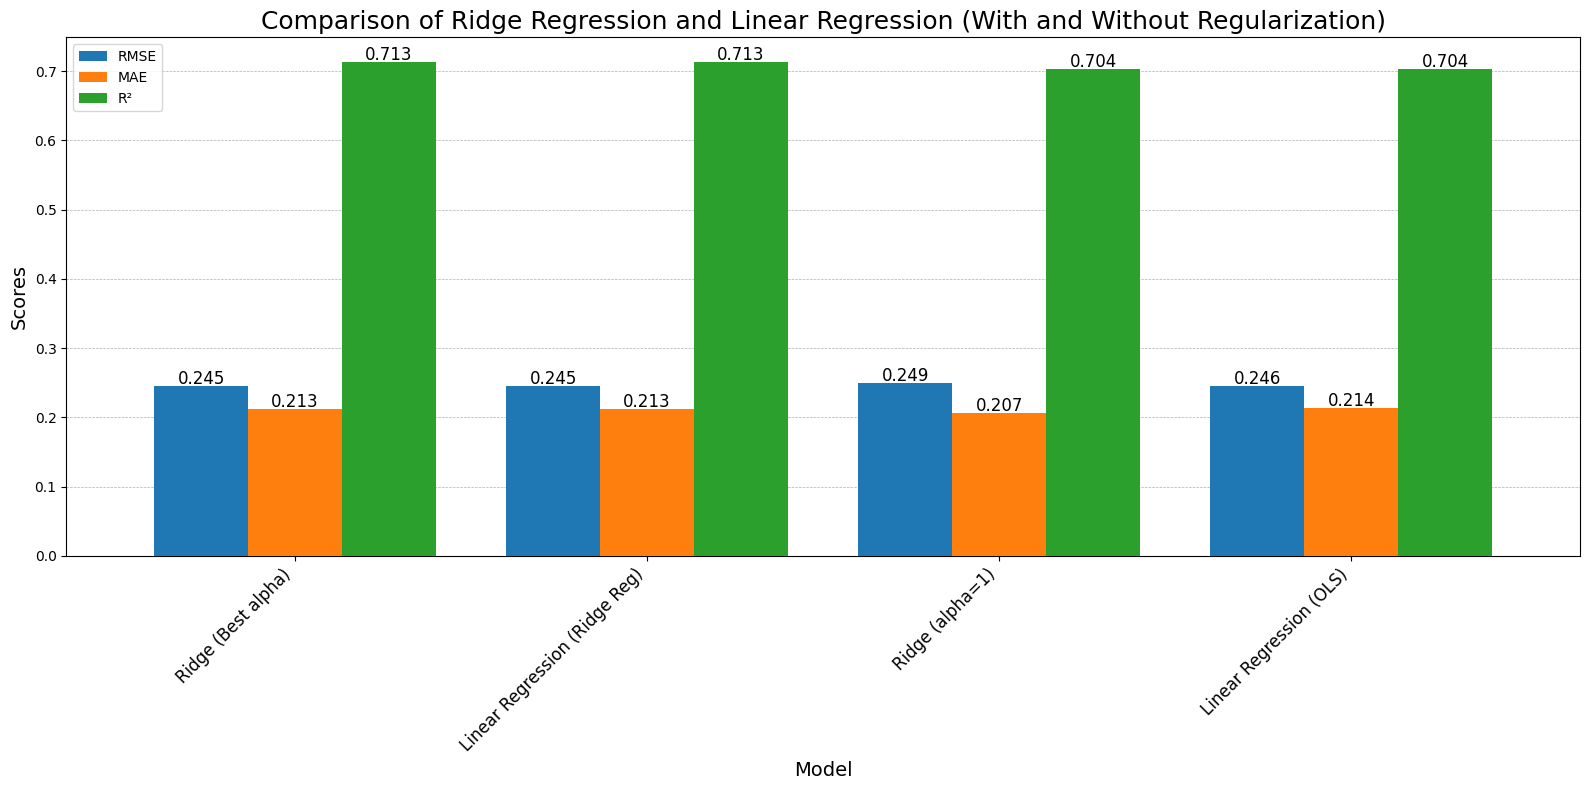

In [60]:
# Prepared a DataFrame containing evaluation metrics (RMSE, MAE, R²) for each model for easy comparison.
# Create a bar plot to visually compare the performance of different models (Ridge, Linear Regression) based on evaluation metrics.
# Add value labels on top of each bar, rotate x-axis labels, and customize the plot for better readability and presentation.

import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the data for visualization
model_names = ['Ridge (Best alpha)', 'Linear Regression (Ridge Reg)', 'Ridge (alpha=1)', 'Linear Regression (OLS)']
rmse_values = [ridge_rmse, linear_rmse, ridge_rmse_alpha_1, rmse_no_reg]
mae_values = [ridge_mae, linear_mae, ridge_mae_alpha_1, mae_no_reg]
r2_values = [ridge_r2, linear_r2, ridge_r2_alpha_1, r2_no_reg]

# Create a DataFrame for easy plotting
results_df = pd.DataFrame({
    'Model': model_names,
    'RMSE': rmse_values,
    'MAE': mae_values,
    'R²': r2_values
})

# Set up the figure size for better readability
plt.figure(figsize=(16, 8))

# Plot the evaluation metrics comparison with adjusted width for more visible separation between bars
ax = results_df.set_index('Model').plot(kind='bar', figsize=(16, 8), width=0.8, 
                                         color=['#1f77b4', '#ff7f0e', '#2ca02c'], zorder=3)

# Adding title and labels
plt.title('Comparison of Ridge Regression and Linear Regression (With and Without Regularization)', fontsize=18, zorder=3)
plt.ylabel('Scores', fontsize=14, zorder=3)
plt.xlabel('Model', fontsize=14, zorder=3)

# Rotate the x-axis labels for better readability and position them correctly
plt.xticks(rotation=45, ha='right', fontsize=12)

# Adjust the layout to avoid overlapping
plt.tight_layout()

# Add the value labels on top of each bar for better visibility of the actual metrics
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=12, color='black', xytext=(0, 5), textcoords='offset points')

# Show grid for better visual alignment
plt.grid(True, which='both', axis='y', linestyle='--', linewidth=0.5, zorder=0)

# Display the plot
plt.show()

In [61]:
# Used the trained riidge regularized linear regression model to predict income for the 2018 test data.
# Displayed the predicted income for the first 5 individuals to check the output.

# Use the trained Ridge model to predict income for the 2018 data
predicted_income_2018 = linear_model.predict(X_test_processed_2018)

# Display the predicted income
print(f"Predicted Income for the first 5 individuals in 2018 data: {predicted_income_2018[:5]}")

Predicted Income for the first 5 individuals in 2018 data: [7.08680577 7.4418614  7.62821077 7.64273529 7.25811471]


In [62]:
# Exponentiate the predictions to get back to the original scale
predicted_income_original_scale = np.exp(predicted_income_2018)

# Display the converted predictions
print(f"Predicted Income (Original Scale) for the first 5 individuals in 2018 data: {predicted_income_original_scale[:5]}")

Predicted Income (Original Scale) for the first 5 individuals in 2018 data: [1196.08113831 1705.92267774 2055.36920509 2085.44030597 1419.57769499]


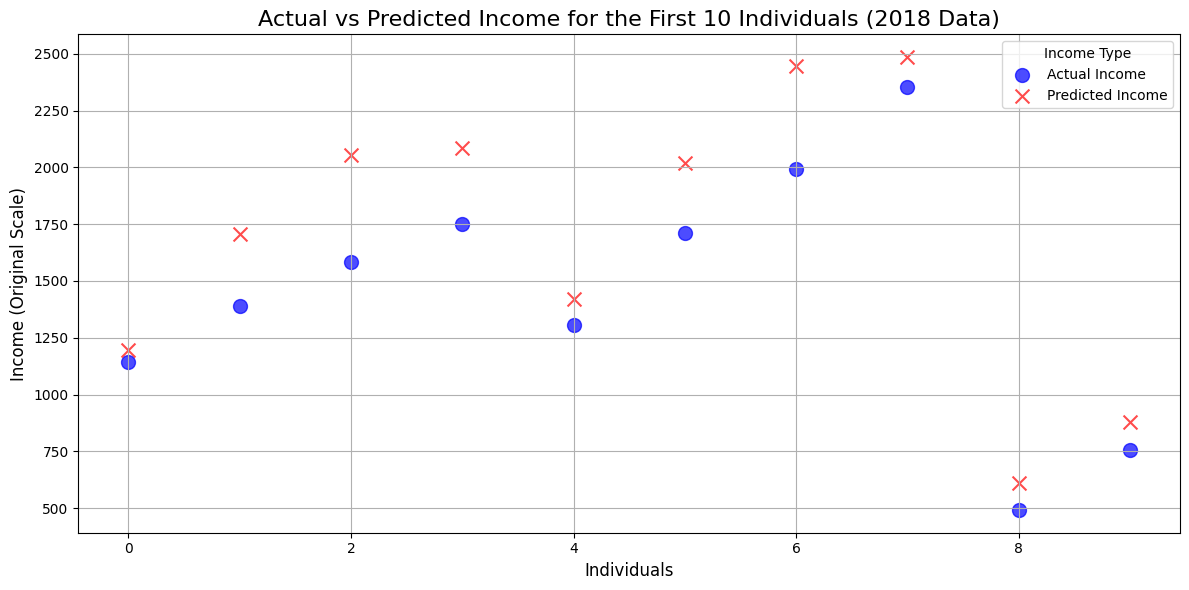

In [64]:
# Exponentiated back the log-transformed actual income values to convert them back to the original scale for proper comparison.
# Plot the actual income (in blue) and predicted income (in red) for the first 10 individuals to visualize the model’s prediction accuracy.
# Customize the plot with titles, axis labels, and a legend for clear distinction between actual and predicted values.

import matplotlib.pyplot as plt


# Exponentiate the actual income values to convert them back to the original scale
actual_income_original_scale = np.exp(y_test_2018[:10])  # Assuming y_test_2018 is log-transformed

# Plot: Actual vs Predicted Income for the first 10 samples
plt.figure(figsize=(12, 6))

# Plot actual income (blue) and predicted income (red) with markers
plt.scatter(range(10), actual_income_original_scale, color='blue', label='Actual Income', marker='o', alpha=0.7, s=100)
plt.scatter(range(10), predicted_income_original_scale[:10], color='red', label='Predicted Income', marker='x', alpha=0.7, s=100)

# Adding labels, title, and legend
plt.title('Actual vs Predicted Income for the First 10 Individuals (2018 Data)', fontsize=16)
plt.xlabel('Individuals', fontsize=12)
plt.ylabel('Income (Original Scale)', fontsize=12)
plt.legend(title="Income Type")
plt.grid(True)
plt.tight_layout()

# Display the plot
plt.show()